# 0 - Importation des modules

In [1]:
from modules.data_collector import download_prices, clean_prices
from modules.base_builder import build_fund_database
from modules.base_update import run_monday_update
from modules.performances import run_performance_report
import pandas as pd

# I - Acquisition des données

In [2]:
# Dates du projet
start_date = "2022-10-01"
end_date = "2024-12-31"

# Dictionnaire des tickers
dict_tickers = {
    # Actions
    "AAPL": "Apple",
    "MSFT": "Microsoft",
    "AMZN": "Amazon",
    "GOOGL": "Alphabet",
    "NVDA": "Nvidia",
    "JPM": "JPMorgan",
    "JNJ": "Johnson & Johnson",
    "PG": "Procter & Gamble",
    "XOM": "Exxon Mobil",
    "KO": "Coca-Cola",
    "WMT": "Walmart",
    "TSLA": "Tesla",

    # Obligations
    "TLT": "US 20Y Treasury Bond ETF",
    "AGG": "US 20Y Treasury Bond ETF",
    "IEF": "US 7-10Y Treasury Bond ETF",
    "AGG": "US Aggregate Bond ETF",
    "LQD": "Investment Grade Corporate Bond ETF",
    "JNK": "High Yield Bond ETF",

    # Commodités
    "USO": "Oil ETF",
    "UNG": "Natural Gas ETF",
    "DBC": "Commodity Index ETF",

    # Or
    "GLD": "Gold ETF",

    # Données macro
    "^VIX": "Volatility Index",
    "^TNX": "US 10Y Yield",

    # Benchmark répliqué tradeable
    "SPY": "S&P 500 ETF",

    # Benchmark officiel non tradeable
    "^GSPC": "S&P 500 Index"
}

# Liste des tickers
tickers = list(dict_tickers.keys())

# Téléchargement des données brutes
prices = download_prices(
    tickers=tickers,
    start=start_date,
    end=end_date
)

# Nettoyage des données
clean = clean_prices(prices)
clean.head()


c:\Users\Sainato\Documents\M1\Data management\Projet\modules\data_collector.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=end, group_by="column")
[*********************100%***********************]  25 of 25 completed


Ticker,AAPL,AGG,AMZN,DBC,GLD,GOOGL,IEF,JNJ,JNK,JPM,...,SPY,TLT,TSLA,UNG,USO,WMT,XOM,^GSPC,^VIX,^TNX
Date,,,,,,,,,,,,,,,,,,,,,
2022-10-04,143.555969,86.067574,121.089996,21.849165,160.699997,100.806839,86.590210,149.417816,70.412555,103.339851,...,360.683655,90.705109,249.440002,93.959999,70.279999,42.892609,84.681320,3790.929932,29.070000,3.617
2022-10-05,143.850739,85.615837,120.949997,22.240726,159.809998,100.598549,85.770134,148.957703,70.170471,102.063950,...,359.843903,89.837830,240.809998,95.760002,71.940002,42.467674,88.103416,3783.280029,28.549999,3.759
2022-10-06,142.897629,85.279259,120.300003,22.379948,159.630005,100.588638,85.297722,146.070786,69.944010,99.983635,...,356.131836,89.338478,238.130005,95.360001,72.989998,42.071499,90.716667,3744.520020,30.520000,3.826
2022-10-07,137.650604,84.827515,114.559998,22.614883,157.880005,97.871109,84.878738,144.528046,69.163116,97.986549,...,346.197906,88.471199,223.070007,91.760002,75.099998,41.074654,89.801125,3639.659912,31.360001,3.883
2022-10-10,137.974854,84.446655,113.669998,22.362547,155.479996,97.057823,84.379555,144.717514,68.288535,97.071228,...,343.554596,87.095795,222.960007,89.800003,73.779999,41.317486,87.854538,3612.389893,32.450001,3.888


# II - Création de la structure de données du fond

In [3]:
build_fund_database(dict_tickers)

Base Fund.db créée et entièrement peuplée.


# III - Stratégies

In [4]:
all_dates = pd.date_range(start=start_date, end=end_date, freq="D")
mondays   = [d for d in all_dates if d.weekday() == 0]

eval_start = pd.Timestamp("2023-01-01")
for date in mondays:
    if date >= eval_start:
        run_monday_update(close_prices=clean, date=date)


 Monday 02/01/2023
  Lundi 02/01 : portefeuille 1 "Low Risk" -> acheter IEF, AGG, DBC, JNJ
  Lundi 02/01 : portefeuille 2 "Low Turnover" -> acheter XOM, KO, GLD, JNJ, JPM, PG
  Lundi 02/01 : portefeuille 3 "High Yield Equity Only" -> acheter XOM, KO, WMT, JNJ, JPM, PG, NVDA

 Monday 09/01/2023
  Lundi 09/01 : portefeuille 1 "Low Risk" -> aucun deal
  Lundi 09/01 : portefeuille 2 "Low Turnover" -> aucun deal
  Lundi 09/01 : portefeuille 3 "High Yield Equity Only" -> acheter MSFT, GOOGL

 Monday 16/01/2023
  Lundi 16/01 : portefeuille 1 "Low Risk" -> aucun deal
  Lundi 16/01 : portefeuille 2 "Low Turnover" -> aucun deal
  Lundi 16/01 : portefeuille 3 "High Yield Equity Only" -> aucun deal

 Monday 23/01/2023
  Lundi 23/01 : portefeuille 1 "Low Risk" -> aucun deal
  Lundi 23/01 : portefeuille 2 "Low Turnover" -> aucun deal
  Lundi 23/01 : portefeuille 3 "High Yield Equity Only" -> vendre WMT, MSFT, JNJ

 Monday 30/01/2023
  Lundi 30/01 : portefeuille 1 "Low Risk" -> acheter KO
  Lundi 30

# IV - Performance


   RAPPORT DE PERFORMANCE - FONDS MULTI-ASSET (2023-2024)

METRIQUES PAR PORTEFEUILLE

              Rdt ann. (%)  Vol. ann. (%)  Sharpe  Max DD (%)   Beta  Alpha ann. (%)  Meilleur mois (%)  Pire mois (%)  Deals/mois (moy.)
Portfolio ID                                                                                                                             
1                     5.25           7.21   0.173       -6.75  0.312           -4.91               4.09          -5.07               5.54
2                    45.75          16.45   2.539      -10.00  1.025           14.47               8.61          -3.85               2.17
3                    51.18          16.77   2.813      -10.60  1.104           16.60               8.47          -5.19               5.00

--------------------------------------------------
  CLASSEMENT DES MANAGERS
--------------------------------------------------

  Sur quel critere voulez-vous classer les managers ?
    1. Rendement annualise
    2. Rati

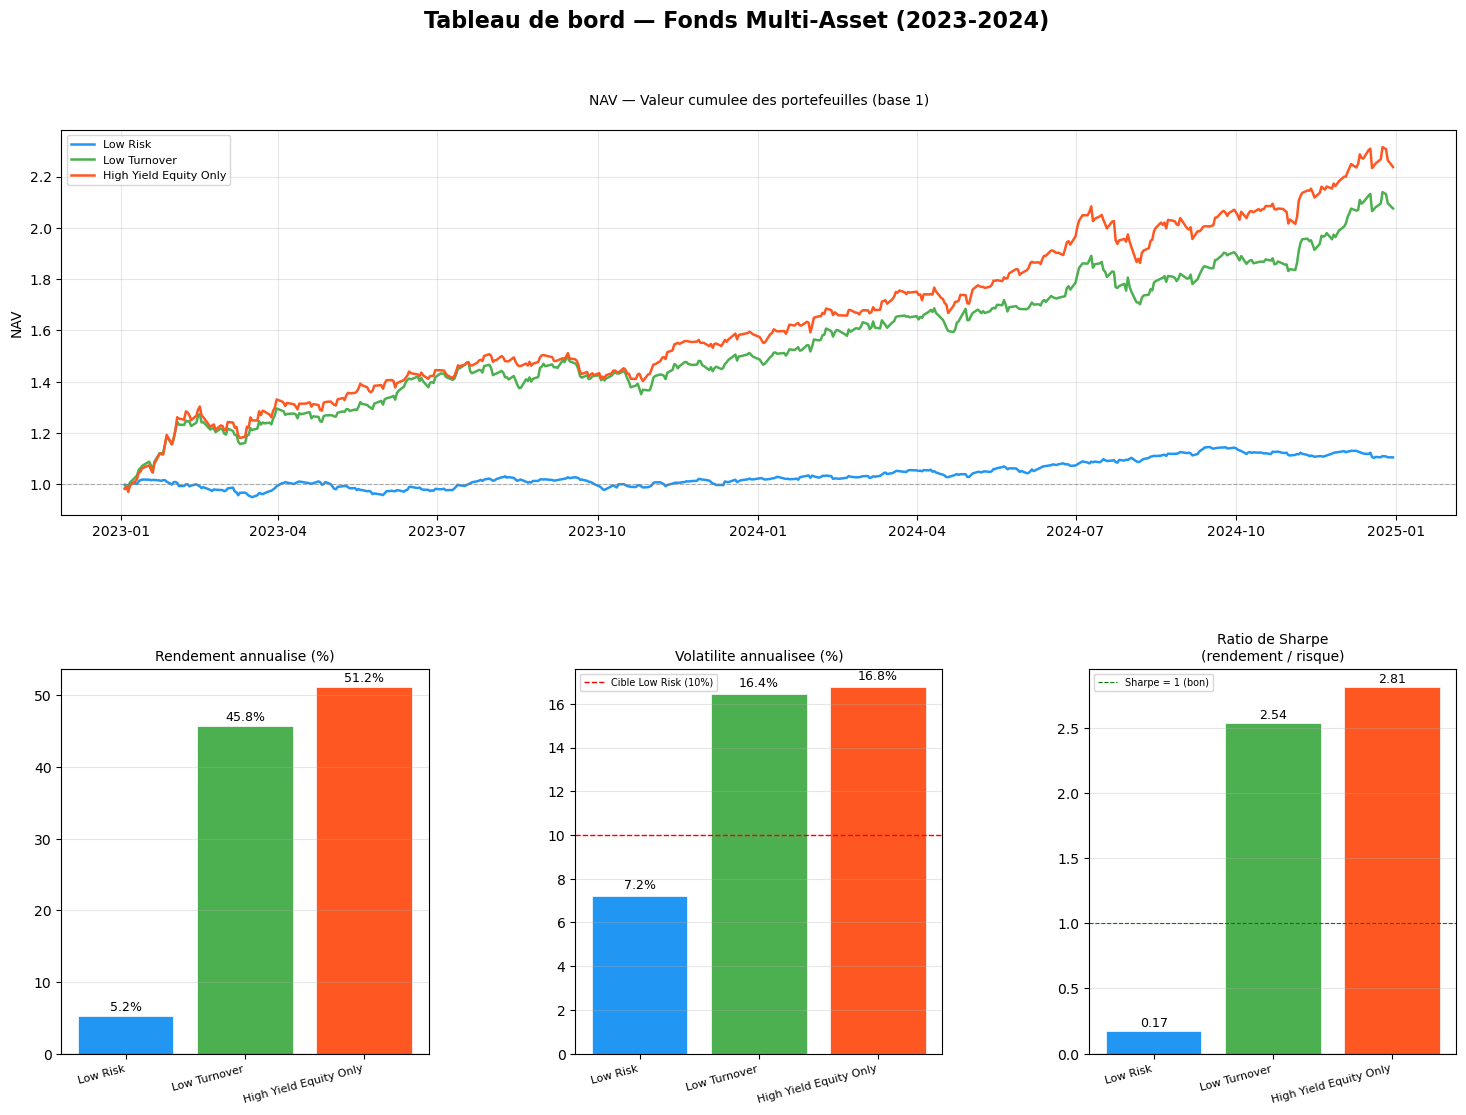


  Dashboard sauvegarde -> performance_dashboard.png

  Rapport termine.



In [5]:
run_performance_report(db_path="db/Fund.db")